In [3]:
import pybamm
import os
from matplotlib import pyplot as plt

from scr.SPMe import Solid_Phase, Cell, Electrolyte
from scr.utils.pinn import FFNN, DeepONet, NN_TL_Diffusion
from scr.utils.parameters import load_params

import torch
import numpy as np

def RMSELoss(yhat, y):
    return torch.sqrt(torch.mean((yhat-y)**2))

In [23]:
parameters = load_params()

model_elec = NN_TL_Diffusion(general_layers=[64, 64, 64, 64], fine_layers=[32, 32], dim_in=3, dim_int=32,
                              dim_out=1, dropout=0.)
elec_model = Electrolyte(model_elec, parameters, [1., 1., 1.], criterion=RMSELoss)

elec_model.load_model(os.path.join("../models/elec_model.pt"))
test_beta = 1.0


# Evaluation
# param = pybamm.ParameterValues("ORegan2022")
param = pybamm.ParameterValues("Chen2020")
param['Electrolyte diffusivity [m2.s-1]'] = lambda c, T:  1.7694e-10  # 4.862e-10 #  8.794e-11 * (c*1000)**2 - 3.972e-10 * (c*1000)**2 + 4.862e-10#
# param['Electrolyte diffusivity [m2.s-1]'] = lambda c, T:  8.794e-11 * (c/1000)**2 - 3.972e-10 * (c/1000) + 4.862e-10
PBM_model = pybamm.lithium_ion.SPMe()
experiment = pybamm.Experiment(["Discharge at " + str(test_beta) + "C for 100000 seconds or until 2.5 V"])
sim = pybamm.Simulation(PBM_model, experiment=experiment, parameter_values=param)
sol = sim.solve(initial_soc=1)

ce = sol["Electrolyte concentration [mol.m-3]"]

# pos_SPM_r0 = sol['X-averaged positive particle concentration'].entries[0, :]
# pos_SPM_r1 = sol['X-averaged positive particle concentration'].entries[-1, :]

t = sol["Time [s]"].entries
x = sol["x [m]"].entries[:, 0]

ce_t0 = ce(t=t[0], x=x)
ce_tend = ce(t=t[-1], x=x)

t_end = t[-1]

t = np.linspace(0, t_end, num=len(ce_tend)) / elec_model.tc

elec_model.update_tc(1.)

bcs_sample_x = torch.linspace(0., 1., 1000)
bcs_sample_t = torch.zeros_like(bcs_sample_x)
bcs_sample_I = torch.ones_like(bcs_sample_t) * test_beta
bcs_sample = torch.stack([bcs_sample_t, bcs_sample_x, bcs_sample_I]).t()
ce_PINN_t0 = elec_model(bcs_sample)

bcs_sample_t = torch.ones_like(bcs_sample_x)
bcs_sample = torch.stack([bcs_sample_t, bcs_sample_x, bcs_sample_I]).t()
ce_PINN_tend = elec_model(bcs_sample)

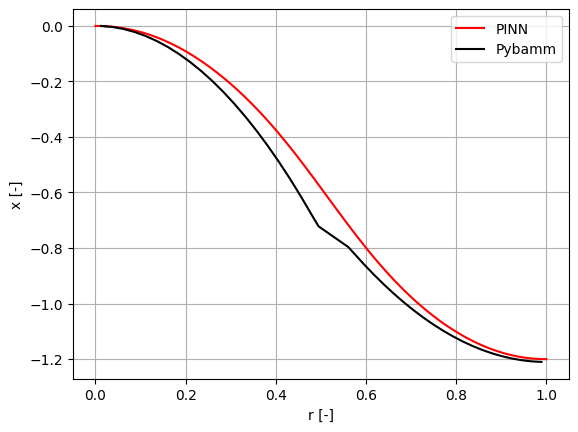

In [4]:
plt.figure()
plt.grid()
# plt.plot(bcs_sample_t.detach().numpy() * PINN_elec.tc / 3600., ce_PINN_t0.detach().numpy(), "k", label="PINN")
# plt.plot(t, ce_t0, "r", label="Pybamm")
plt.plot(bcs_sample_x.detach().numpy() * elec_model.tc / 3600., (ce_PINN_tend - ce_PINN_tend[0]).detach().numpy(),
         "r", label="PINN")
plt.plot(x / parameters["L"], (ce_tend - ce_tend[0]) / parameters["ce0"], "k", label="Pybamm")
plt.legend()
plt.xlabel("r [-]")
plt.ylabel("x [-]")
plt.show()

In [86]:
bcs_sample_x = torch.linspace(0., 1., 1000)
bcs_sample_I = torch.ones_like(bcs_sample_t) * test_beta * 1.

bcs_sample_t = torch.ones_like(bcs_sample_x)
bcs_sample = torch.stack([bcs_sample_t, bcs_sample_x, bcs_sample_I]).t()

In [87]:
x = torch.tensor(bcs_sample, requires_grad=True)

c = elec_model(x) #/ elec_model(x)

i_app = x[:, 2] * parameters["I_typ"] / parameters["A"]

dcdx = torch.autograd.grad(c, x, grad_outputs=torch.ones_like(c),
                           create_graph=True)[0]

L_n = parameters["L_n"] / parameters["L"]
L_s = parameters["L_s"] / parameters["L"]

idx_Ln = x[:, 1] < L_n
idx_Lp = x[:, 1] > L_n + L_s
idx_Ls = (L_n <= x[:, 1]) & (x[:, 1] <= L_n + L_s)

left = dcdx[:, 0] * parameters["ce0"] / 3600. # * parameters["por_n"]
# left = torch.zeros_like(c)
left[idx_Ln] *= parameters["por_n"]
left[idx_Ls] *= parameters["por_s"]
left[idx_Lp] *= parameters["por_p"]

De_eff = torch.ones_like(c) * parameters["D_e_const"]
# De_eff = parameters["D_e"](c)
De_eff[idx_Ln] *= (parameters["por_n"] ** parameters["brug"])
De_eff[idx_Ls] *= (parameters["por_s"] ** parameters["brug"])
De_eff[idx_Lp] *= (parameters["por_p"] ** parameters["brug"])
right = torch.autograd.grad(De_eff * dcdx[:, 1], x, grad_outputs=torch.ones_like(c),
                            create_graph=True)[0][:, 1]

right *= parameters["ce0"] / parameters["L"] ** 2

right[idx_Ln] += i_app[idx_Ln] / (parameters["F"] * parameters["L_n"]) * (1 - parameters["t_plus"])
right[idx_Lp] -= i_app[idx_Lp] / (parameters["F"] * parameters["L_p"]) * (1 - parameters["t_plus"])

res = left - right
res

tensor([-1.0621e+00, -1.0512e+00, -1.0403e+00, -1.0295e+00, -1.0188e+00,
        -1.0081e+00, -9.9745e-01, -9.8689e-01, -9.7639e-01, -9.6596e-01,
        -9.5560e-01, -9.4530e-01, -9.3507e-01, -9.2490e-01, -9.1480e-01,
        -9.0477e-01, -8.9481e-01, -8.8492e-01, -8.7510e-01, -8.6534e-01,
        -8.5566e-01, -8.4605e-01, -8.3651e-01, -8.2704e-01, -8.1765e-01,
        -8.0832e-01, -7.9907e-01, -7.8990e-01, -7.8080e-01, -7.7177e-01,
        -7.6282e-01, -7.5395e-01, -7.4515e-01, -7.3643e-01, -7.2778e-01,
        -7.1921e-01, -7.1072e-01, -7.0231e-01, -6.9397e-01, -6.8572e-01,
        -6.7754e-01, -6.6944e-01, -6.6142e-01, -6.5349e-01, -6.4563e-01,
        -6.3785e-01, -6.3015e-01, -6.2254e-01, -6.1501e-01, -6.0756e-01,
        -6.0019e-01, -5.9290e-01, -5.8570e-01, -5.7857e-01, -5.7154e-01,
        -5.6458e-01, -5.5771e-01, -5.5092e-01, -5.4422e-01, -5.3760e-01,
        -5.3106e-01, -5.2461e-01, -5.1824e-01, -5.1196e-01, -5.0576e-01,
        -4.9965e-01, -4.9362e-01, -4.8767e-01, -4.8

In [85]:
right_2C = torch.tensor(right)

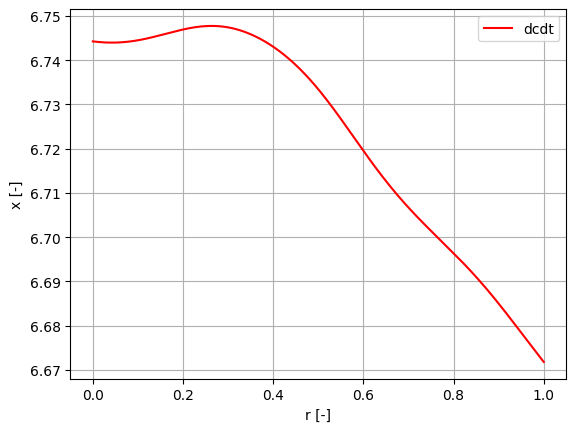

In [73]:
plt.figure()
plt.grid()
# plt.plot(bcs_sample_t.detach().numpy() * PINN_elec.tc / 3600., ce_PINN_t0.detach().numpy(), "k", label="PINN")
# plt.plot(t, ce_t0, "r", label="Pybamm")
plt.plot(bcs_sample_x.detach().numpy() * elec_model.tc / 3600., dcdx[:, 0].detach().numpy(),
         "r", label="dcdt")
plt.legend()
plt.xlabel("r [-]")
plt.ylabel("x [-]")
plt.show()

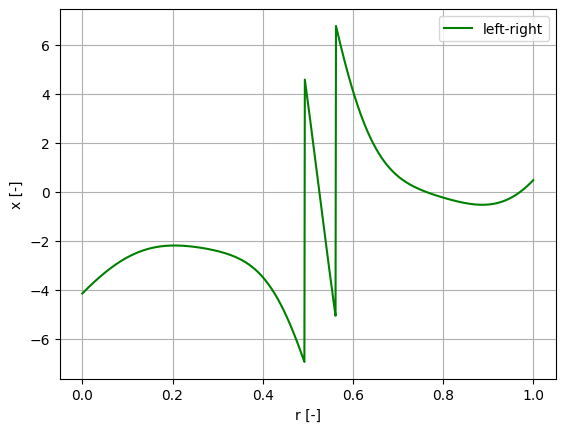

In [79]:
plt.figure()
plt.grid()
# plt.plot(bcs_sample_t.detach().numpy() * PINN_elec.tc / 3600., ce_PINN_t0.detach().numpy(), "k", label="PINN")
# plt.plot(t, ce_t0, "r", label="Pybamm")
plt.plot(bcs_sample_x.detach().numpy() * elec_model.tc / 3600., res.detach().numpy(),
         "g", label="left-right")
plt.legend()
plt.xlabel("r [-]")
plt.ylabel("x [-]")
plt.show()

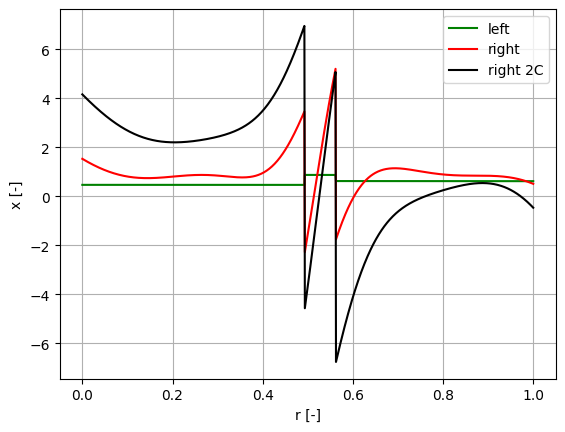

In [89]:
plt.figure()
plt.grid()
# plt.plot(bcs_sample_t.detach().numpy() * PINN_elec.tc / 3600., ce_PINN_t0.detach().numpy(), "k", label="PINN")
# plt.plot(t, ce_t0, "r", label="Pybamm")
plt.plot(bcs_sample_x.detach().numpy() * elec_model.tc / 3600., left.detach().numpy(),
         "g", label="left")
plt.plot(bcs_sample_x.detach().numpy() * elec_model.tc / 3600., right.detach().numpy(),
         "r", label="right")
plt.plot(bcs_sample_x.detach().numpy() * elec_model.tc / 3600., right_2C.detach().numpy(),
         "k", label="right 2C")
plt.legend()
plt.xlabel("r [-]")
plt.ylabel("x [-]")
plt.show()

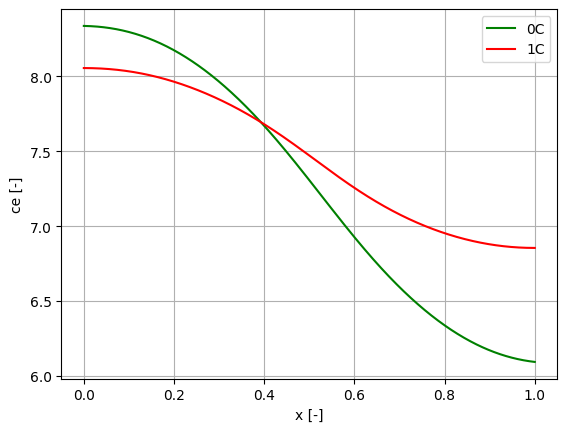

In [68]:
plt.figure()
plt.grid()
# plt.plot(bcs_sample_t.detach().numpy() * PINN_elec.tc / 3600., ce_PINN_t0.detach().numpy(), "k", label="PINN")
# plt.plot(t, ce_t0, "r", label="Pybamm")
plt.plot(bcs_sample_x.detach().numpy() * elec_model.tc / 3600., c.detach().numpy(),
         "g", label="0C")
plt.plot(bcs_sample_x.detach().numpy() * elec_model.tc / 3600., ce_PINN_tend.detach().numpy(),
         "r", label="1C")
plt.legend()
plt.xlabel("x [-]")
plt.ylabel("ce [-]")
plt.show()

In [12]:
c

tensor([8.0550, 8.0550, 8.0550, 8.0550, 8.0550, 8.0550, 8.0549, 8.0549, 8.0549,
        8.0548, 8.0548, 8.0547, 8.0547, 8.0546, 8.0546, 8.0545, 8.0544, 8.0544,
        8.0543, 8.0542, 8.0541, 8.0541, 8.0540, 8.0539, 8.0538, 8.0537, 8.0536,
        8.0534, 8.0533, 8.0532, 8.0531, 8.0530, 8.0528, 8.0527, 8.0525, 8.0524,
        8.0522, 8.0521, 8.0519, 8.0518, 8.0516, 8.0514, 8.0512, 8.0511, 8.0509,
        8.0507, 8.0505, 8.0503, 8.0501, 8.0499, 8.0497, 8.0495, 8.0492, 8.0490,
        8.0488, 8.0485, 8.0483, 8.0481, 8.0478, 8.0476, 8.0473, 8.0470, 8.0468,
        8.0465, 8.0462, 8.0459, 8.0457, 8.0454, 8.0451, 8.0448, 8.0445, 8.0442,
        8.0438, 8.0435, 8.0432, 8.0429, 8.0425, 8.0422, 8.0419, 8.0415, 8.0412,
        8.0408, 8.0404, 8.0401, 8.0397, 8.0393, 8.0390, 8.0386, 8.0382, 8.0378,
        8.0374, 8.0370, 8.0366, 8.0362, 8.0357, 8.0353, 8.0349, 8.0345, 8.0340,
        8.0336, 8.0331, 8.0327, 8.0322, 8.0318, 8.0313, 8.0308, 8.0303, 8.0299,
        8.0294, 8.0289, 8.0284, 8.0279, 

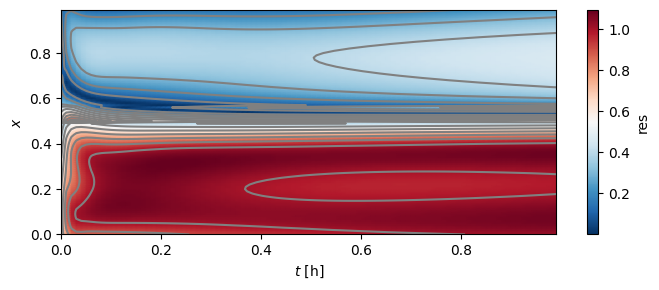

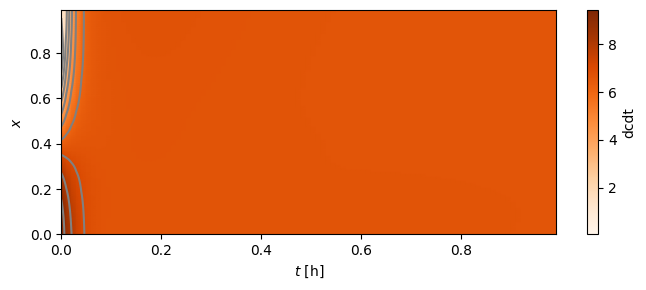

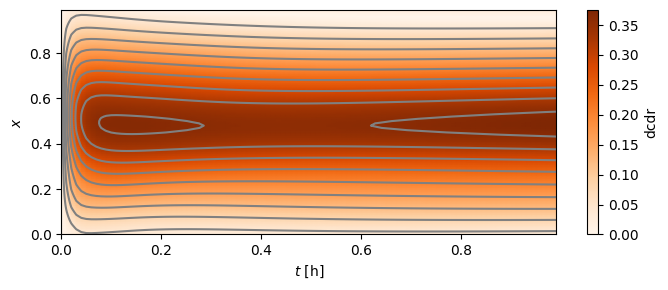

In [19]:
num = 1000.

t_test = (torch.arange(0, num, dtype=torch.float, requires_grad=True) / num)[::10]
r_rand = (torch.arange(0, num, dtype=torch.float, requires_grad=True) / num)[::10]

t_new, r_new = torch.meshgrid(t_test, r_rand)
pos = np.zeros_like(t_new.detach().numpy())

pos_dcdt = np.zeros_like(t_new.detach().numpy())
pos_dcdr = np.zeros_like(t_new.detach().numpy())

for i, (t, r) in enumerate(zip(t_new, r_new)):
    cur = torch.ones_like(t) * 0.
    residuals = elec_model.compute_residuals(torch.stack((t, r, cur)).t())
    pos[i, :] = np.abs(residuals.detach().numpy())
    gradients = elec_model.compute_gradients(torch.stack((t, r, cur)).t())
    pos_dcdt[i, :] = np.abs(gradients[:, 0].detach().numpy())
    pos_dcdr[i, :] = np.abs(gradients[:, 1].detach().numpy())


def plot_area(points, style, cmap_label):
    plt.subplots(figsize=(7, 3), tight_layout=True)
    plot = plt.pcolormesh(t_new.detach().numpy(), r_new.detach().numpy(), points, cmap=style, shading='gouraud')
    cbar = plt.colorbar(plot)
    plt.contour(t_new.detach().numpy(), r_new.detach().numpy(), points, 10, colors='gray')
    plt.ylabel('$x$')
    plt.xlabel('$t$ [h]')
    cbar.set_label(cmap_label)
    # plt.savefig('/content/drive/MyDrive/Datos/con_PINN_pos.png')
    plt.show()


plot_area(pos, 'RdBu_r', 'res')
plot_area(pos_dcdt, 'Oranges', 'dcdt')
plot_area(pos_dcdr, 'Oranges', 'dcdr')